<a href="https://colab.research.google.com/github/BillJr99/Ursinus-CS357-Fall2025/blob/gh-pages/files/notebooks/Bigram_Word_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!/usr/bin/env python3
"""
Bigram Explorer: tokenization, bigram counts, conditional histograms, and stochastic generation.

Workflow (interactive once launched):
    1) You will be asked for a single word W. The program plots the histogram of the top-k followers of W.
       It then samples one next word according to the empirical probabilities and prints it.
    2) You will be asked for a seed sentence. The program will iteratively generate more words
       by repeatedly sampling the next word conditioned on the current last word.
"""

from __future__ import annotations
import collections
import math
import os
import random
import re
import sys
import traceback
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Iterable, Optional
import requests
from urllib.parse import urlparse
import matplotlib.pyplot as plt


In [ ]:
# ----------------------------
# Text & Tokenization Utilities
# ----------------------------

_WORD_RE = re.compile(r"[A-Za-z0-9']+")

def read_text(path_or_url: str) -> str:
  def _is_url(path_or_url: str) -> bool:
      """
      Return True if the given string looks like a URL, False otherwise.
      """
      try:
          result = urlparse(path_or_url)
          return all([result.scheme, result.netloc])
      except Exception as e:
          print(f"[is_url] Error: {e}")
          import traceback; traceback.print_exc()
          return False

    """
    Read raw text from either:
      - a local UTF-8 file path, or
      - an HTTP/HTTPS URL (using requests), with simple encoding handling.
    """
    if _is_url(path_or_url):
        try:
            # Some servers are picky without a UA.
            headers = {"User-Agent": "Mozilla/5.0 (compatible; BigramExplorer/1.0)"}
            resp = requests.get(path_or_url, headers=headers, timeout=20)
            resp.raise_for_status()
            # Prefer server-declared encoding; fall back to apparent or UTF-8.
            enc = resp.encoding or getattr(resp, "apparent_encoding", None) or "utf-8"
            resp.encoding = enc
            return resp.text
        except Exception as e:
            print(f"[read_text/url] {e}")
            traceback.print_exc()
            raise
    else:
        if not os.path.isfile(path_or_url):
            raise FileNotFoundError(f"[read_text] File not found: {path_or_url}")
        try:
            with open(path_or_url, "r", encoding="utf-8", errors="ignore") as f:
                return f.read()
        except Exception as e:
            print(f"[read_text/file] {e}")
            traceback.print_exc()
            raise

def normalize_and_tokenize(text: str) -> List[str]:
    """
    Normalize and tokenize text:
      - Lowercase
      - Keep alphanumerics and apostrophes inside words (e.g., don't -> "don't")
      - Return list of word strings (no punctuation tokens)
    """
    text = text.lower()
    return _WORD_RE.findall(text)

def build_vocab(tokens: Iterable[str]) -> Tuple[Dict[str, int], List[str]]:
    """
    Build a bijective mapping between words and integer token IDs.
    Returns (word2id, id2word) where id2word[id] = word and word2id[word] = id.
    """
    vocab = sorted(set(tokens))
    id2word = list(vocab)
    word2id = {w: i for i, w in enumerate(id2word)}
    return word2id, id2word

def encode_tokens(tokens: Iterable[str], word2id: Dict[str, int]) -> List[int]:
    """Map token strings to their integer IDs (unknown words are skipped)."""
    ids = []
    for w in tokens:
        if w in word2id:
            ids.append(word2id[w])
    return ids

In [ ]:
# ----------------------------
# Bigram Construction
# ----------------------------

def build_bigram_structures(
    token_ids: List[int],
) -> Tuple[Dict[Tuple[int, int], int], List[Dict[Tuple[int, int], int]]]:
    """
    Build:
      - bigram_counts: dict mapping (id_i, id_{i+1}) -> count
      - per_occurrence_dicts: list of dicts, each with a single {(id_i, id_{i+1}): 1}
        (This directly satisfies “put these dicts into an array”.)
    """
    bigram_counts: Dict[Tuple[int, int], int] = defaultdict(int)
    per_occurrence_dicts: List[Dict[Tuple[int, int], int]] = []

    for i in range(len(token_ids) - 1):
        pair = (token_ids[i], token_ids[i + 1])
        bigram_counts[pair] += 1
        per_occurrence_dicts.append({pair: 1})

    return dict(bigram_counts), per_occurrence_dicts

def build_followers_index(
    bigram_counts: Dict[Tuple[int, int], int]
) -> Dict[int, Counter]:
    """
    Convert global bigram counts into an adjacency-like index:
      followers[w] = Counter of next-word IDs and their counts.
    """
    followers: Dict[int, Counter] = defaultdict(Counter)
    for (w, nxt), c in bigram_counts.items():
        followers[w][nxt] += c
    return followers

In [ ]:
# ----------------------------
# Analysis & Plotting
# ----------------------------

def frequency_map_for_word(
    word: str,
    word2id: Dict[str, int],
    followers: Dict[int, Counter],
) -> Counter:
    """
    Return a Counter mapping token IDs of words that can follow `word` to frequency counts.
    If the word is not found or has no followers, returns an empty Counter.
    """
    key = word2id.get(word.lower())
    if key is None:
        return Counter()
    return followers.get(key, Counter())

def plot_top_k_followers(
    base_word: str,
    id2word: List[str],
    follower_counts: Counter,
    top_k: int = 15,
    title_prefix: str = "Top followers of",
    show_values: bool = True,
) -> plt.Figure:
    """
    Create a Matplotlib bar chart for the top-k followers of `base_word`.
    Returns the Figure object (also displays it via plt.show()).
    """
    if not follower_counts:
        fig = plt.figure()
        plt.title(f"{title_prefix} '{base_word}' (no data)")
        plt.xlabel("Following word")
        plt.ylabel("Count")
        plt.show()
        return fig

    most_common = follower_counts.most_common(top_k)
    labels = [id2word[w_id] for (w_id, _) in most_common]
    counts = [c for (_, c) in most_common]

    fig = plt.figure()
    plt.bar(range(len(labels)), counts)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.title(f"{title_prefix} '{base_word}'")
    plt.xlabel("Following word")
    plt.ylabel("Count")

    if show_values:
        # Annotate counts above bars
        for i, c in enumerate(counts):
            plt.text(i, c, str(c), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()
    return fig

def select_next_word(
    follower_counts: Counter,
    mode: str = "sample",
    rng: random.Random | None = None,
) -> Optional[int]:
    """
    Select the next word ID from follower_counts.

    mode:
      - "sample": probability-proportional selection (uses rng)
      - "argmax": choose the ID with the highest count (ties broken deterministically)

    Returns None if follower_counts is empty.
    """
    if not follower_counts:
        return None

    if mode == "argmax":
        # Deterministic tie-break: smallest ID among those with max count
        max_count = max(follower_counts.values())
        candidates = [wid for wid, c in follower_counts.items() if c == max_count]
        return min(candidates)
    else:
      # Default: sample proportionally to counts
      items = list(follower_counts.items())
      ids = [wid for (wid, _) in items]
      weights = [cnt for (_, cnt) in items]
      if rng is None:
          rng = random.Random()
      return rng.choices(ids, weights=weights, k=1)[0]


In [ ]:
# ----------------------------
# Interactive Generation
# ----------------------------

def generate_sequence(
    seed_sentence: str,
    steps: int,
    word2id: Dict[str, int],
    id2word: List[str],
    followers: Dict[int, Counter],
    rng: random.Random,
    top_k: int = 15,
    show_hist_each_step: bool = True,
    save_dir: str | None = None,
    selection_mode: str = "sample",  # <- "sample" randomly or "argmax" for top choice
) -> str:
    """
    Iteratively generate `steps` words using either sampling or argmax selection.

    If a word has no followers, generation stops early.

    Additional features:
      - Optional per-step histograms (top_k)
      - Optional saving of each step's histogram to save_dir
    """
    seed_tokens = normalize_and_tokenize(seed_sentence)
    if not seed_tokens:
        return ""

    start_id = None
    for w in reversed(seed_tokens):
        if w in word2id:
            start_id = word2id[w]
            break
    if start_id is None:
        return ""

    if save_dir is not None:
        try:
            os.makedirs(save_dir, exist_ok=True)
        except Exception as e:
            print(f"[generate_sequence/os.makedirs] {e}")
            traceback.print_exc()

    generated_words = []
    current_id = start_id

    for t in range(steps):
        fcounts = followers.get(current_id, Counter())
        current_word = id2word[current_id]

        if show_hist_each_step:
            fig = plot_top_k_followers(
                base_word=current_word,
                id2word=id2word,
                follower_counts=fcounts,
                top_k=top_k,
                title_prefix=f"Step {t+1}: top followers of",
                show_values=True,
            )
            if save_dir is not None:
                try:
                    safe_word = re.sub(r"[^a-zA-Z0-9_]+", "_", current_word)
                    fig.savefig(
                        os.path.join(save_dir, f"step_{t+1}_{safe_word}.png"),
                        dpi=150,
                        bbox_inches="tight",
                    )
                except Exception as e:
                    print(f"[generate_sequence/savefig] {e}")
                    traceback.print_exc()

        nxt = select_next_word(fcounts, mode=selection_mode, rng=rng)
        if nxt is None:
            break

        generated_words.append(id2word[nxt])
        current_id = nxt

    return " ".join(seed_tokens + generated_words)


Enter a word to analyze its following-word histogram: between


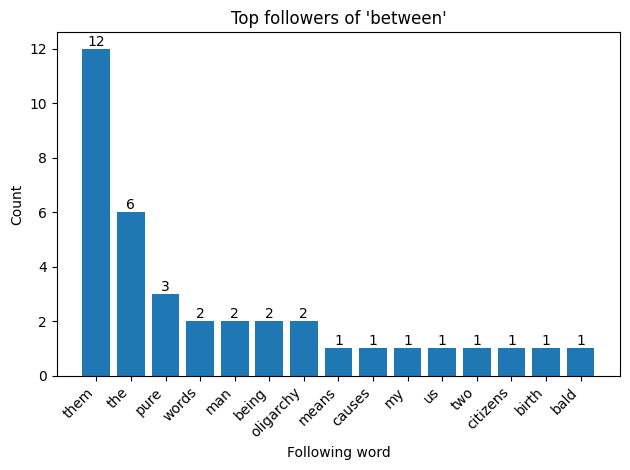

[main] Top-choice next word for 'between': them
Enter a seed sentence for iterative generation: Once upon a


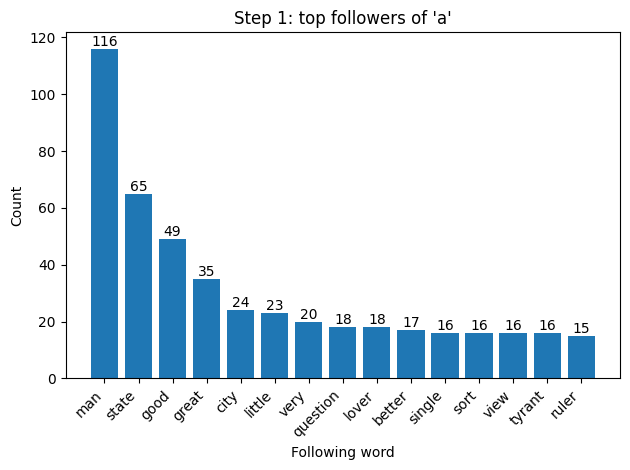

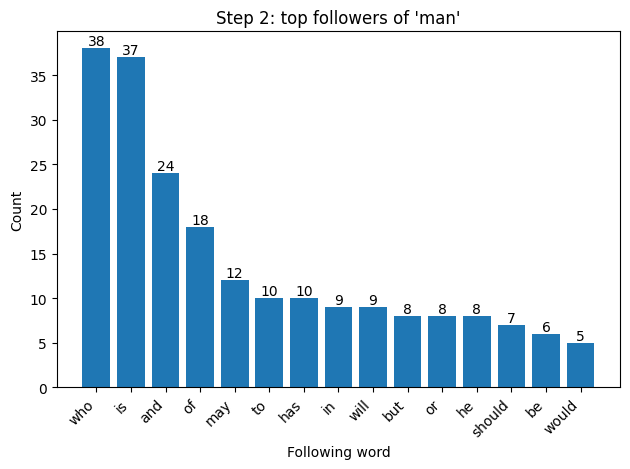

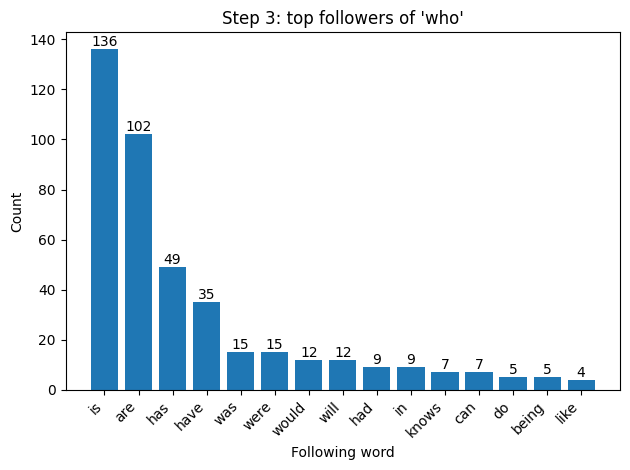

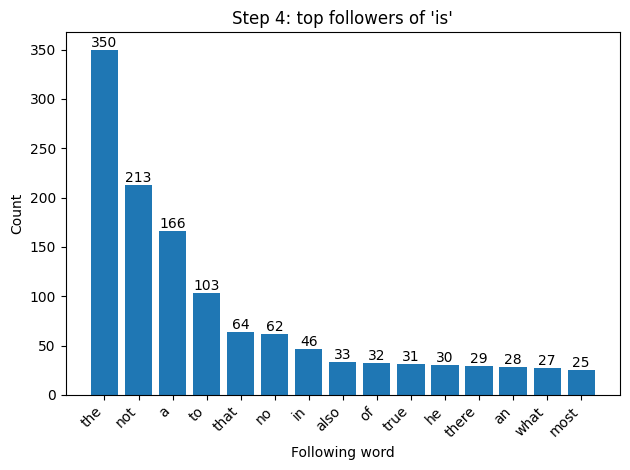

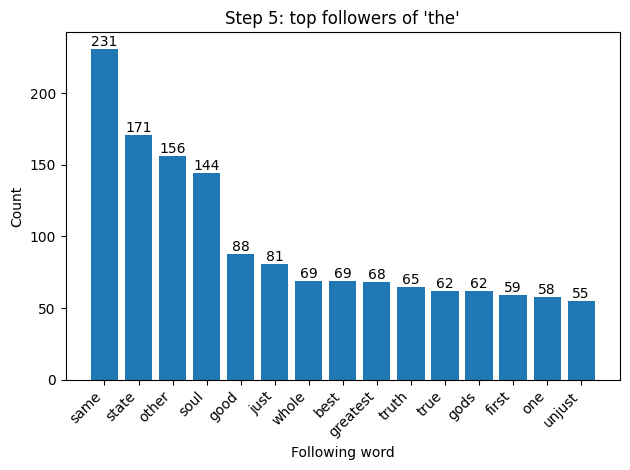

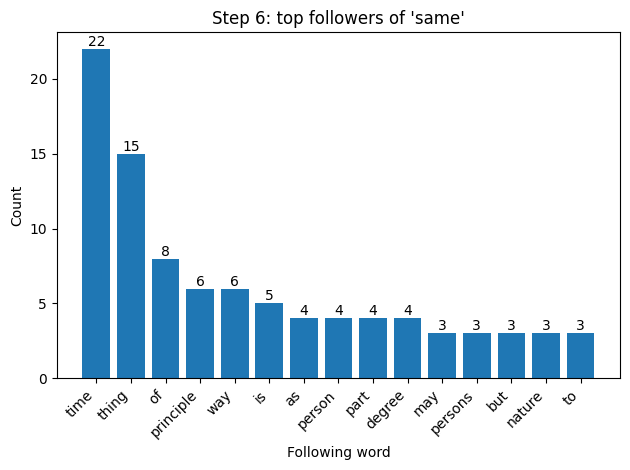

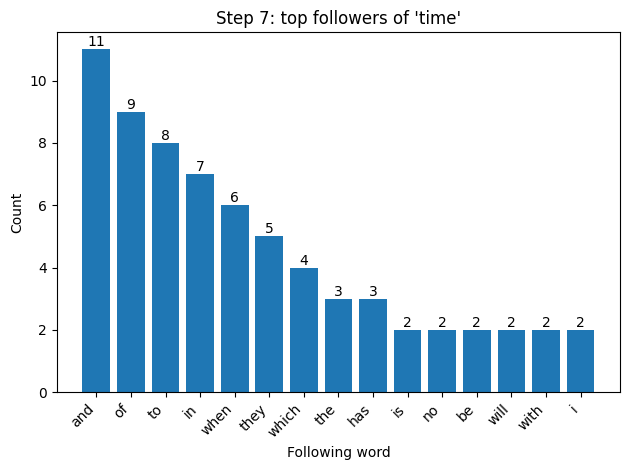

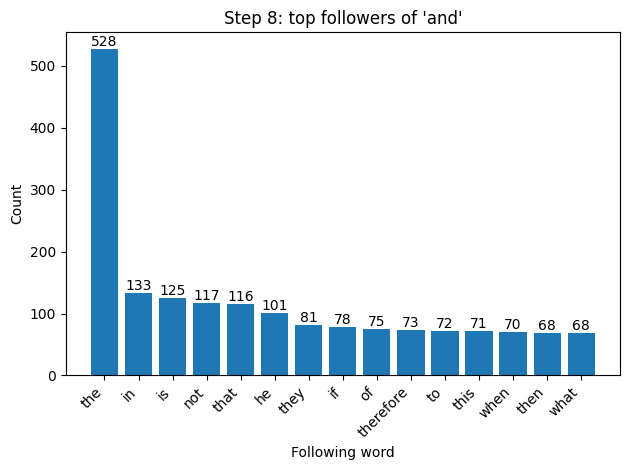

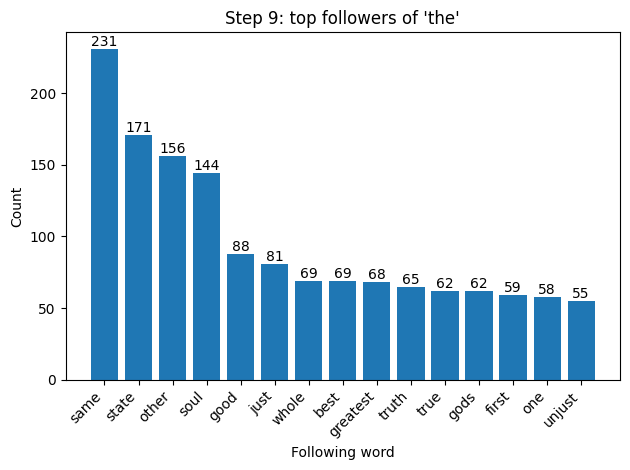

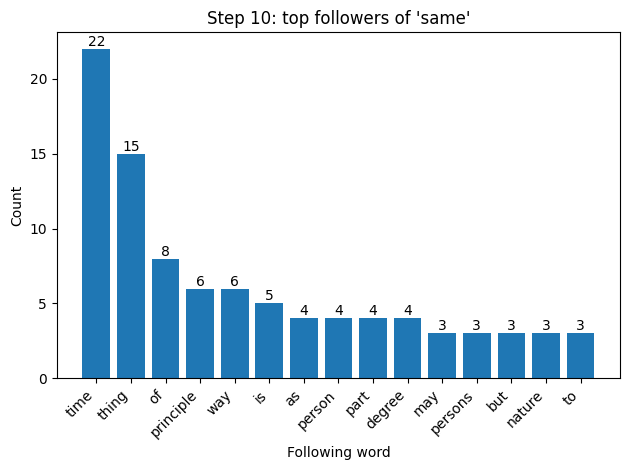

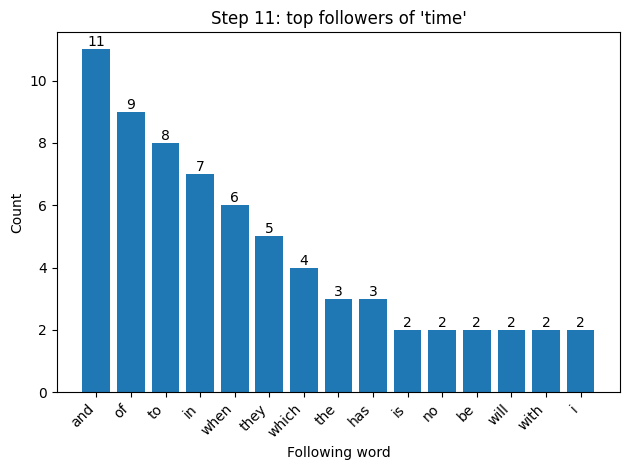

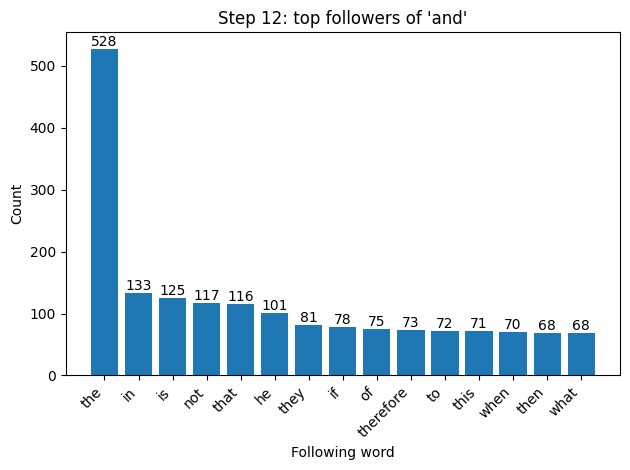

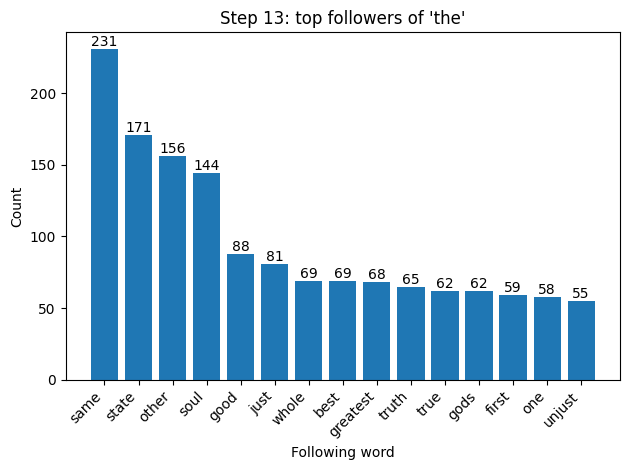

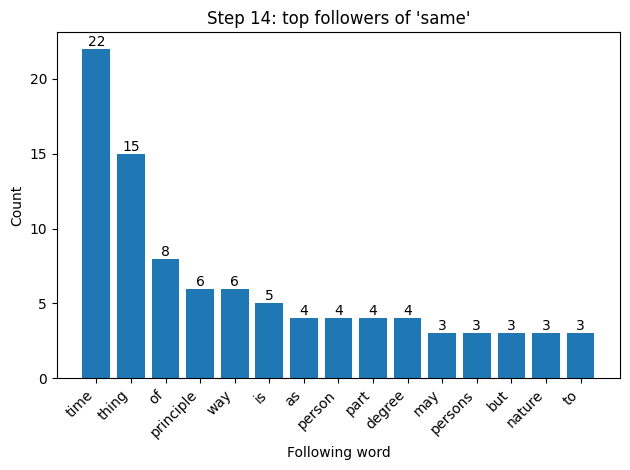

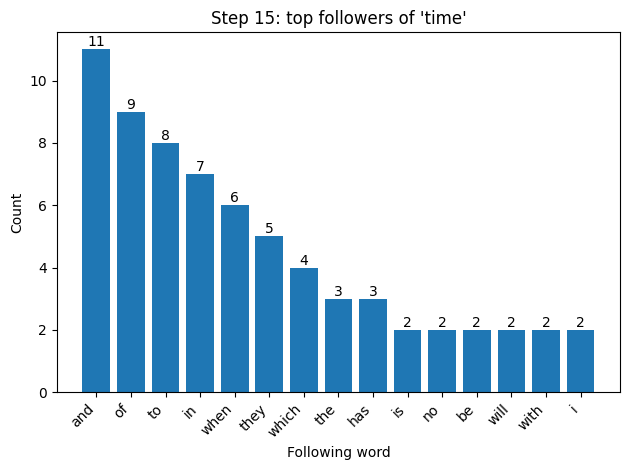

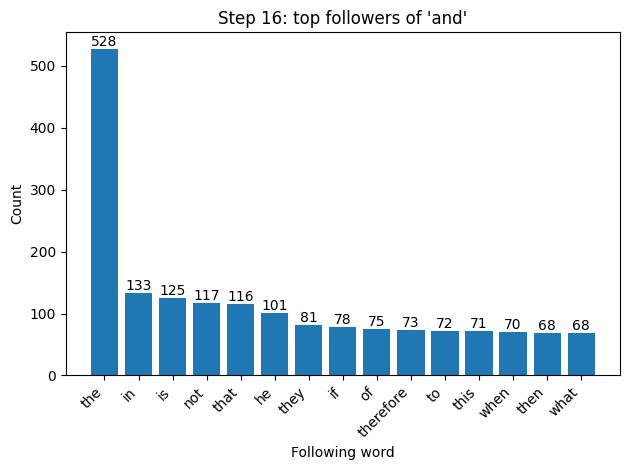

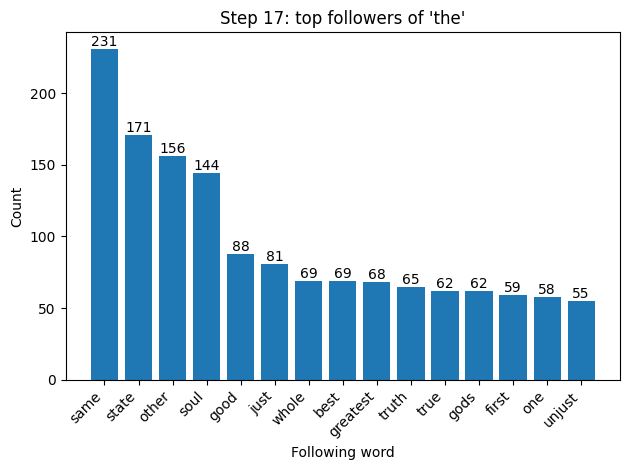

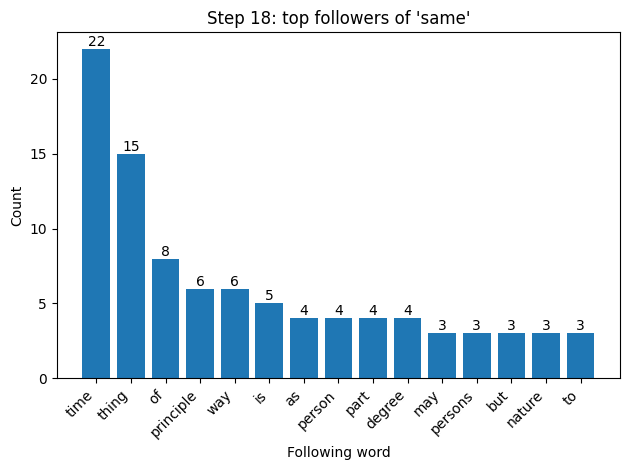

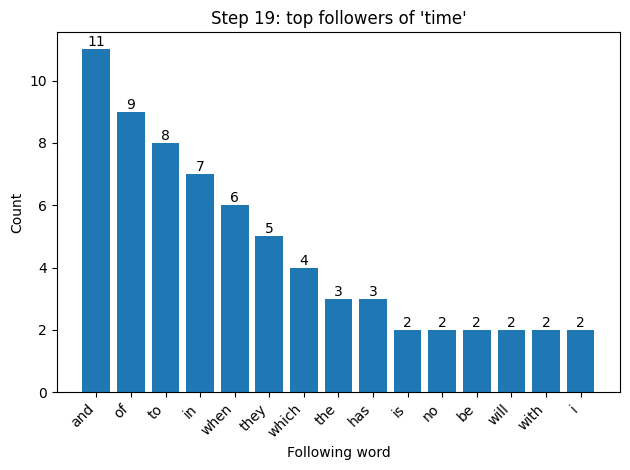

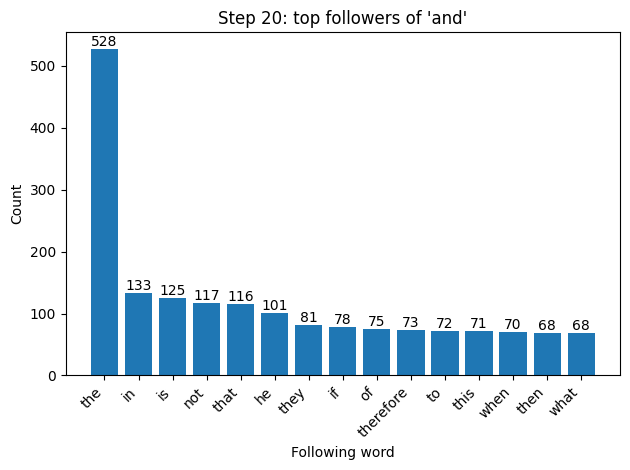

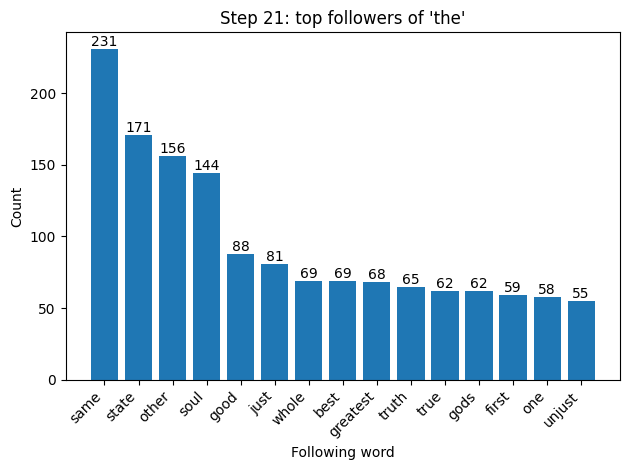

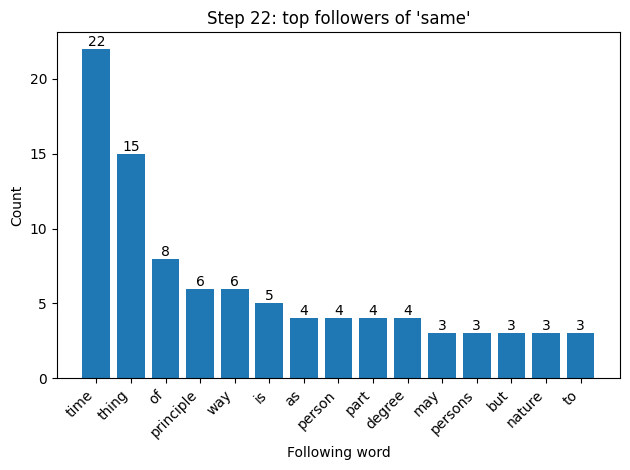

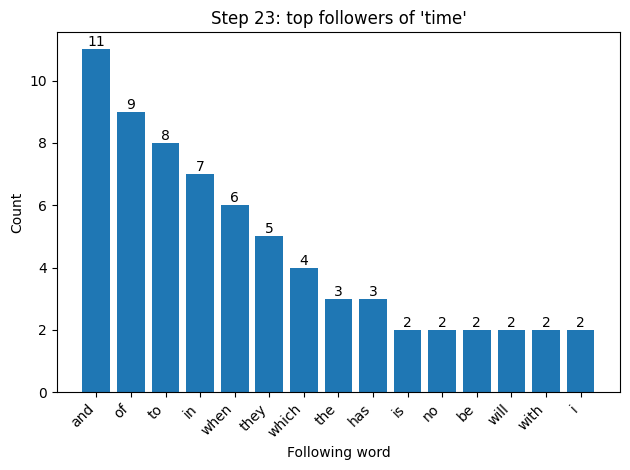

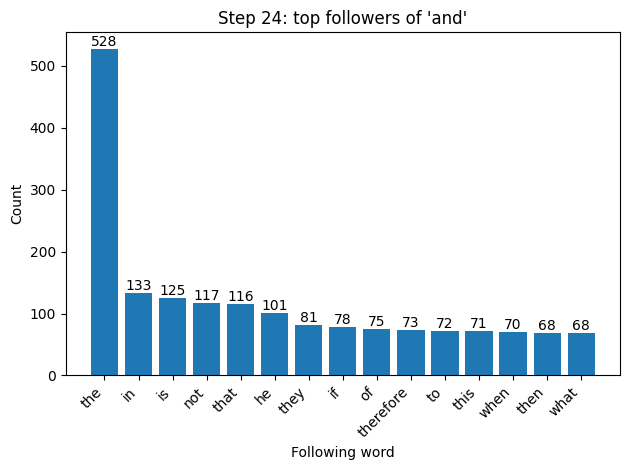

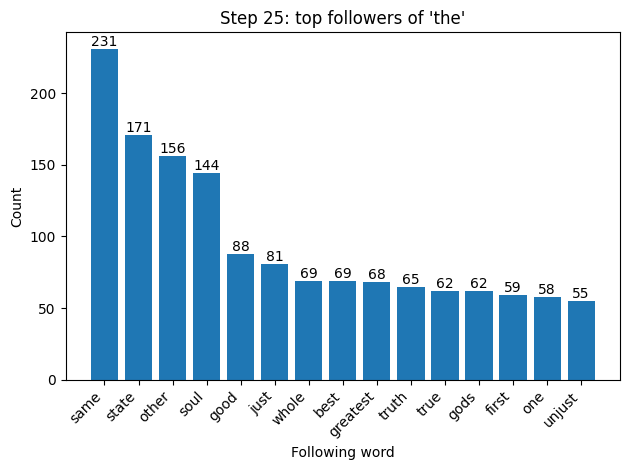


[main] Generated continuation:
once upon a man who is the same time and the same time and the same time and the same time and the same time and the same


In [ ]:
class Config:
    def __init__(
        self,
        # Default to a public-domain text; replace with any URL or a local path.
        input_path: str = "http://classics.mit.edu/Plato/republic.mb.txt",  # The Republic, Plato (public domain)
        top_k: int = 15,
        steps: int = 25,
        seed: int = 123,
        save_plot: str | None = None,
        selection_mode: str = "argmax", # "sample" or "argmax"
    ):
        self.input_path = input_path
        self.top_k = top_k
        self.steps = steps
        self.seed = seed
        self.save_plot = save_plot
        self.selection_mode = selection_mode

def main(config: Config | None = None) -> None:
    if config is None:
        config = Config()

    rng = random.Random(config.seed)

    try:
        raw = read_text(config.input_path)
    except Exception as e:
        print(f"[main/read_text] {e}")
        traceback.print_exc()
        return

    tokens = normalize_and_tokenize(raw)
    if not tokens:
        print("[main] No tokens found in the input after normalization.")
        return

    word2id, id2word = build_vocab(tokens)
    token_ids = encode_tokens(tokens, word2id)

    bigram_counts, per_occurrence_dicts = build_bigram_structures(token_ids)
    followers = build_followers_index(bigram_counts)

    # 1) Ask user for a word and plot histogram of top-k followers
    word = input("Enter a word to analyze its following-word histogram: ").strip().lower()

    fcounts = frequency_map_for_word(word, word2id, followers)
    fig = plot_top_k_followers(word, id2word, fcounts, top_k=config.top_k)

    if config.save_plot is not None:
        try:
            fig.savefig(config.save_plot, dpi=150, bbox_inches="tight")
            print(f"[main] Saved histogram to: {config.save_plot}")
        except Exception as e:
            print(f"[main/savefig] {e}")
            traceback.print_exc()

    # Sample one next word (proportional to counts) or take most likely word per argmax in config above, and print
    nxt_id = select_next_word(fcounts, mode=config.selection_mode, rng=rng)
    if nxt_id is None:
        print(f"[main] No followers found for '{word}'.")
    else:
        label = "Top-choice" if config.selection_mode == "argmax" else "Randomly sampled"
        print(f"[main] {label} next word for '{word}': {id2word[nxt_id]}")

    # 2) Iterative generation from a user-provided seed sentence
    seed_sentence = input("Enter a seed sentence for iterative generation: ").strip()

    continuation = generate_sequence(
        seed_sentence=seed_sentence,
        steps=config.steps,
        word2id=word2id,
        id2word=id2word,
        followers=followers,
        rng=rng,
        top_k=config.top_k,
        show_hist_each_step=True,
        save_dir=None,
        selection_mode=config.selection_mode,
    )
    if continuation:
        print("\n[main] Generated continuation:")
        print(continuation)
    else:
        print("[main] Could not generate continuation (seed lacked in-vocab words or no outgoing bigrams).")

if __name__ == "__main__":
  main()